<a href="https://colab.research.google.com/github/anshumansharma-cse/OCT-Eye-Disease-Classification/blob/main/OCT_Classify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Eye Disease Prediction Sysytem

In [ ]:
# Environment Setup
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.18.1
NumPy: 2.0.2


In [ ]:
# Config & GPU Check
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:", gpus)

if gpus:
    print("GPU acceleration is available.")
else:
    print("WARNING: No GPU detected.")

TensorFlow version: 2.18.1
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU acceleration is available.


In [ ]:
# What
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

NUM_CLASSES = 4

CLASS_NAMES = ["CNV", "DME", "DRUSEN", "NORMAL"]

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)
print("Epochs:", EPOCHS)

Image size: (224, 224)
Batch size: 32
Number of classes: 4
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Epochs: 10


In [ ]:
DATA_DIR = "../Dataset/OCT2017"

print("Dataset path:", DATA_DIR)
print("Dataset exists:", os.path.exists(DATA_DIR))

Dataset path: ../Dataset/OCT2017
Dataset exists: True


In [ ]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATA_DIR, split)

    print(f"\n{split.upper()}")
    print("-" * 30)

    for class_name in CLASS_NAMES:
        class_path = os.path.join(split_path, class_name)

        if os.path.exists(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpeg", ".jpg", ".png"))
            ])

            print(f"{class_name:10s}: {count:,}")
        else:
            print(f"{class_name:10s}: NOT FOUND")


TRAIN
------------------------------
CNV       : 37,205
DME       : 11,348
DRUSEN    : 8,616
NORMAL    : 26,315

VAL
------------------------------
CNV       : 8
DME       : 8
DRUSEN    : 8
NORMAL    : 8

TEST
------------------------------
CNV       : 242
DME       : 242
DRUSEN    : 242
NORMAL    : 242


In [ ]:
# load data
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 83484 files belonging to 4 classes.


In [ ]:
# validate dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 32 files belonging to 4 classes.


In [ ]:
# test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 968 files belonging to 4 classes.


In [ ]:
# Data Batch Check
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 2609
Validation batches: 1
Test batches: 31


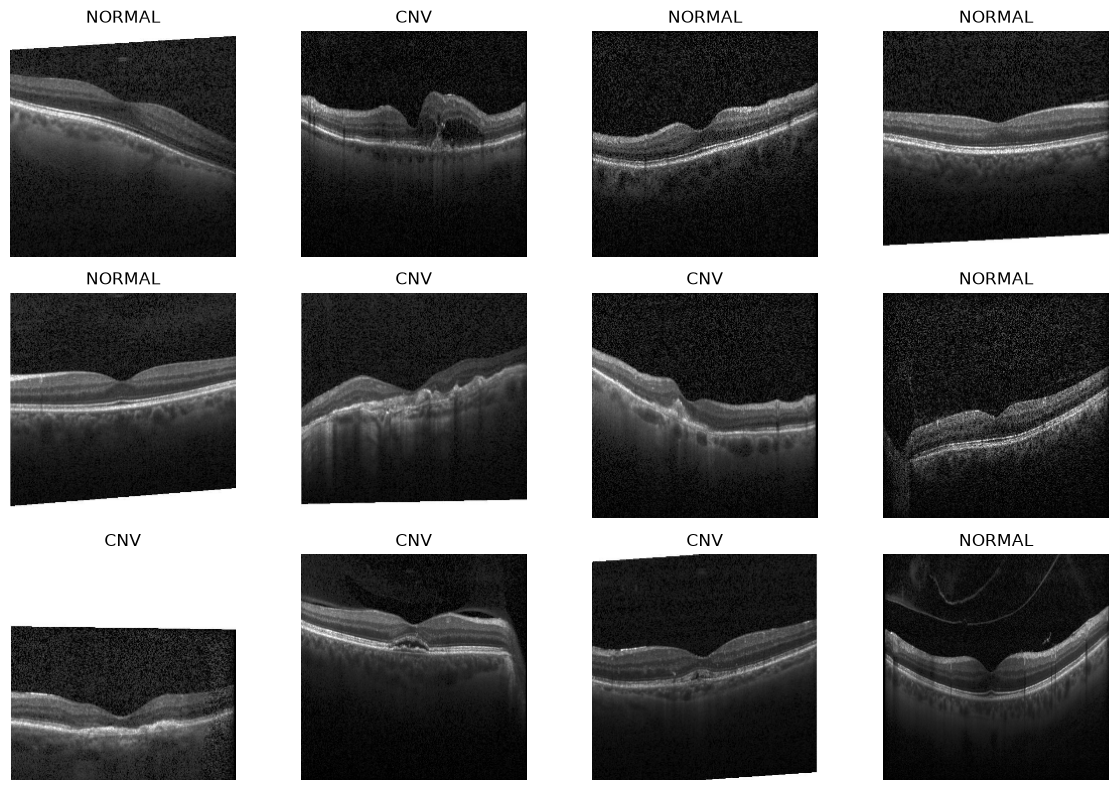

In [ ]:
# Data visualised
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Optimise Data
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
# Augument Data
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)

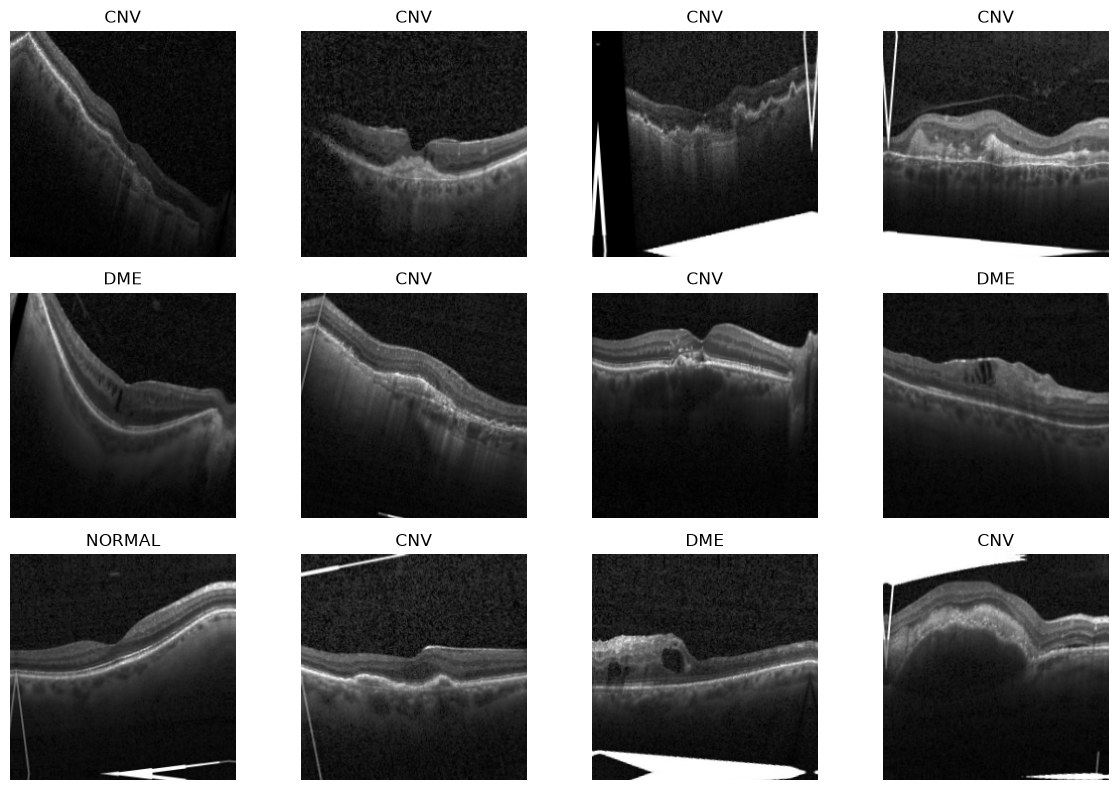

2026-09-28 19:55:25.806675: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# Augumented Data Visualised
for images, labels in train_ds.take(1):

    plt.figure(figsize=(12, 8))

    for i in range(12):
        augmented_image = data_augmentation(
            tf.expand_dims(images[i], axis=0),
            training=True
        )

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.title(CLASS_NAMES[labels[i].numpy()])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Transfer-Learning Mobile-NetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Base model layers:", len(base_model.layers))

Base model layers: 154


In [ ]:
# Model Build
inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="OCT_MobileNetV2"
)

model.summary()

Model: "OCT_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile Model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

# Cell 18- Training MobileNetV2

In [ ]:
# Train Model (GPU-)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10


/Users/anshumansharma/Developer/SRM_Projects/OCT-Eye-Disease-Classification/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-28 20:00:05.262351: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2609/2609 ━━━━━━━━━━━━━━━━━━━━ 511s 193ms/step - accuracy: 0.8045 - loss: 0.5347 - val_accuracy: 0.9375 - val_loss: 0.1752 - learning_rate: 0.0010
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 481s 184ms/step - accuracy: 0.8272 - loss: 0.4788 - val_accuracy: 0.9375 - val_loss: 0.1517 - learning_rate: 0.0010
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 467s 179ms/step - accuracy: 0.8287 - loss: 0.4749 - val_accuracy: 0.8750 - val_loss: 0.1824 - learning_rate: 0.0010
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 493s 189ms/step - accuracy: 0.8282 - loss: 0.4751 - val_accuracy: 0.9062 - val_loss: 0.1579 - learning_rate: 0.0010
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 499s 191ms/step - accuracy: 0.8362 - loss: 0.4507 - val_accuracy: 0.9062 - val_loss: 0.1705 - learning_rate: 2.0000e-04


In [ ]:
print("Epochs actually completed:", len(history.history["loss"]))
print("Best validation accuracy:",
      max(history.history["val_accuracy"]))
print("Best validation loss:",
      min(history.history["val_loss"]))

Epochs actually completed: 5
Best validation accuracy: 0.9375
Best validation loss: 0.1517108678817749


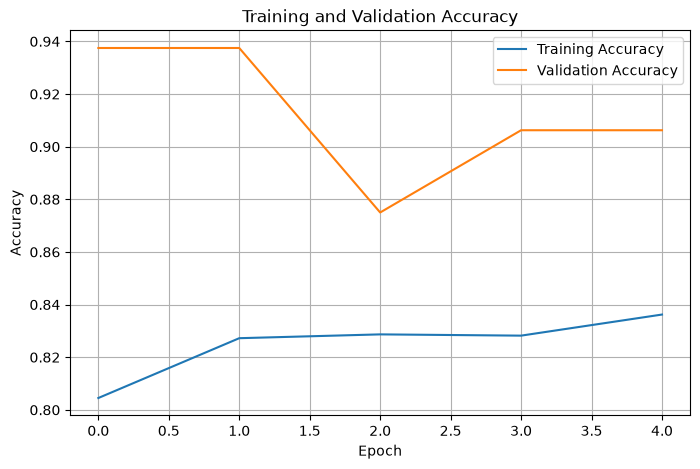

In [ ]:
# Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

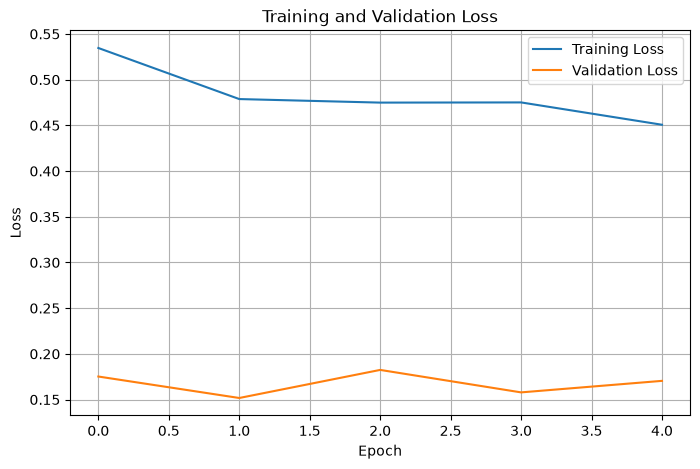

In [ ]:
# Training and Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#  Test Accuracy
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.9194 - loss: 0.2474
Test Loss: 0.24741625785827637
Test Accuracy: 0.9194214940071106


In [ ]:
class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]

y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
)

print("Number of test samples:", len(y_true))
print("Classes:", class_names)

Number of test samples: 968
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [ ]:
# Prediction
y_pred_prob = model.predict(test_ds, verbose=1)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated.")
print("Number of predictions:", len(y_pred))

31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step
Predictions generated.
Number of predictions: 968


In [ ]:
# True Vs Prediction
class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]

print("Class names:", class_names)

for i in range(10):
    print(
        f"Sample {i+1}: "
        f"True = {class_names[y_true[i]]}, "
        f"Predicted = {class_names[y_pred[i]]}"
    )

Class names: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Sample 1: True = CNV, Predicted = CNV
Sample 2: True = CNV, Predicted = CNV
Sample 3: True = CNV, Predicted = CNV
Sample 4: True = CNV, Predicted = CNV
Sample 5: True = CNV, Predicted = CNV
Sample 6: True = CNV, Predicted = CNV
Sample 7: True = CNV, Predicted = CNV
Sample 8: True = CNV, Predicted = CNV
Sample 9: True = CNV, Predicted = CNV
Sample 10: True = CNV, Predicted = DRUSEN


In [ ]:
# Confusion Martrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[230   8   4   0]
 [  7 219   5  11]
 [ 32   0 206   4]
 [  0   1   6 235]]


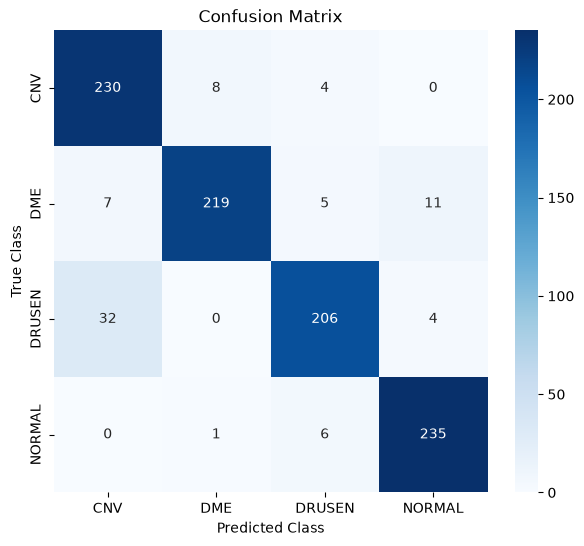

In [ ]:
# Matrix Visuals
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

In [ ]:
# Claasification Report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         CNV       0.86      0.95      0.90       242
         DME       0.96      0.90      0.93       242
      DRUSEN       0.93      0.85      0.89       242
      NORMAL       0.94      0.97      0.96       242

    accuracy                           0.92       968
   macro avg       0.92      0.92      0.92       968
weighted avg       0.92      0.92      0.92       968



In [ ]:
# Eval Metric:

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-Score:", f1)

Weighted Precision: 0.921917899995662
Weighted Recall: 0.9194214876033058
Weighted F1-Score: 0.9193109883184563


In [ ]:
# Summary of Results

print("========== FINAL RESULTS ==========")

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-Score      : {f1:.4f}")

print("===================================")

========== FINAL RESULTS ==========
Test Accuracy : 0.9194
Test Loss     : 0.2474
Precision     : 0.9219
Recall        : 0.9194
F1-Score      : 0.9193


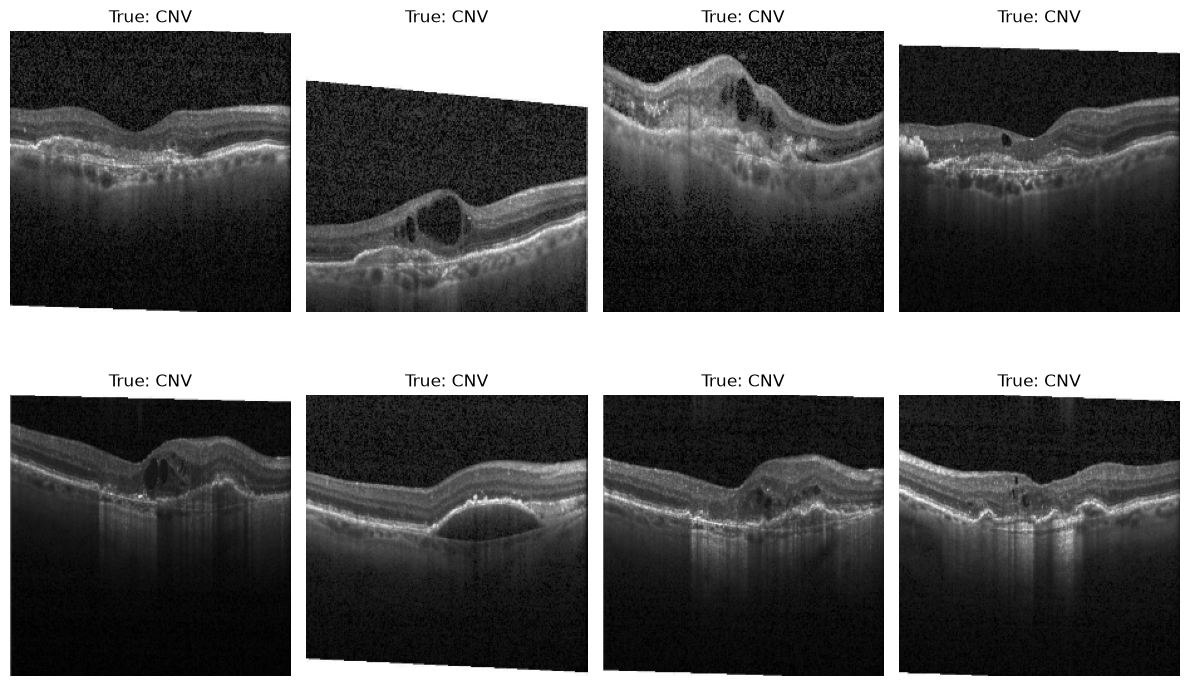

In [ ]:
# Sample Test Images
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i].numpy()]

        plt.title(f"True: {true_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

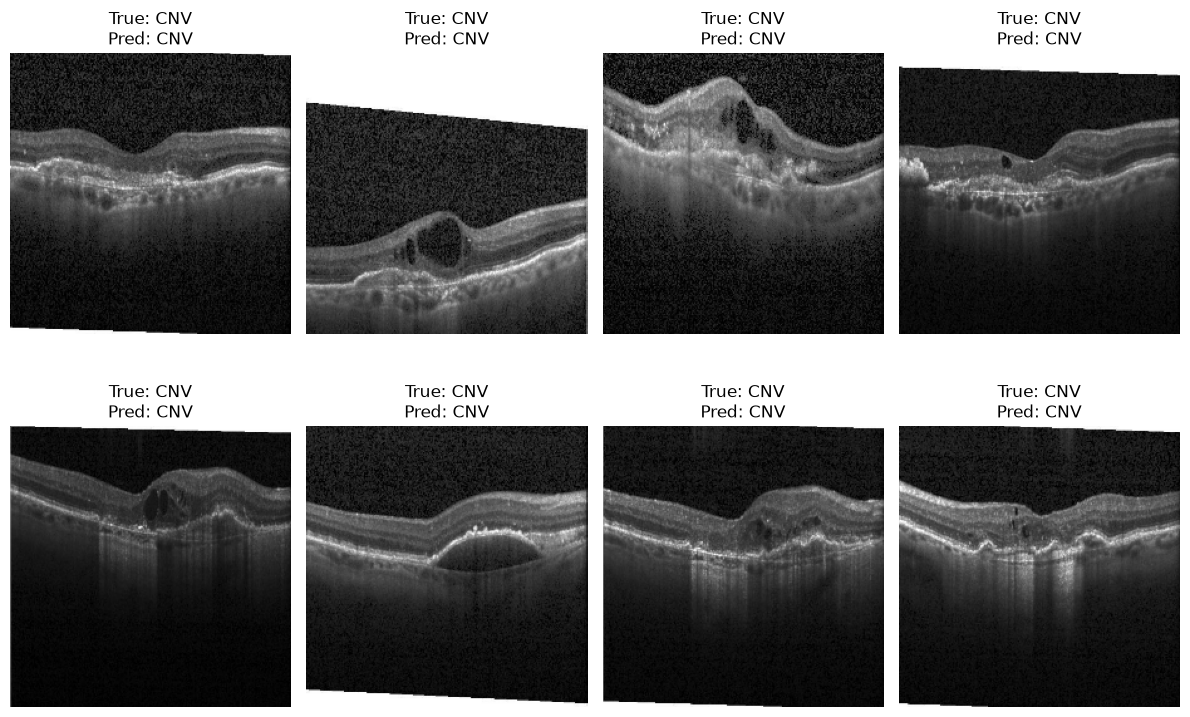

In [ ]:
# Sample Predicitons
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(8):
        plt.subplot(2, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[predicted_labels[i]]

        plt.title(
            f"True: {true_label}\nPred: {predicted_label}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Single Image Prediction

import glob
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Dataset is one level above the notebook directory
normal_images = glob.glob("../Dataset/OCT2017/test/NORMAL/*")

print("Number of NORMAL test images found:", len(normal_images))

# Pick the first available image
image_path = normal_images[0] # Change Image [i]

print("Testing image:")
print(image_path)

# Load image
img = load_img(
    image_path,
    target_size=(224, 224)
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0])

class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]

print()
print("Predicted class:", class_names[predicted_class])
print(f"Confidence: {confidence * 100:.2f}%")

Number of NORMAL test images found: 242
Testing image:
../Dataset/OCT2017/test/NORMAL/NORMAL-3380901-1.jpeg

Predicted class: NORMAL
Confidence: 96.91%


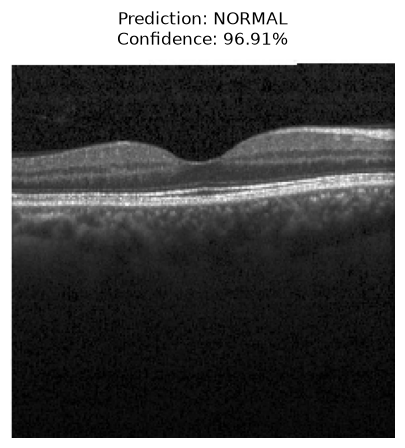

In [ ]:
# Inference Results:
plt.figure(figsize=(5, 5))

plt.imshow(img)

plt.title(
    f"Prediction: {class_names[predicted_class]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

In [ ]:
# Save Model
MODEL_PATH = "oct_mobilenetv2.keras"

model.save(MODEL_PATH)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
oct_mobilenetv2.keras


In [ ]:
# Final Results:
print("=" * 50)
print("OCT RETINAL DISEASE CLASSIFICATION")
print("=" * 50)

print("Model              : MobileNetV2")
print("Framework          : TensorFlow / Keras")
print("Hardware           : Apple M4 GPU (Metal)")
print("Classes            :", ", ".join(class_names))

print()
print(f"Training Epochs    : {len(history.history['loss'])}")
print(f"Best Val Accuracy  : {max(history.history['val_accuracy']):.4f}")
print(f"Test Accuracy      : {test_accuracy:.4f}")
print(f"Test Loss          : {test_loss:.4f}")
print(f"Weighted Precision  : {precision:.4f}")
print(f"Weighted Recall     : {recall:.4f}")
print(f"Weighted F1        : {f1:.4f}")

print("=" * 50)
print("Training and evaluation completed.")

OCT RETINAL DISEASE CLASSIFICATION
Model              : MobileNetV2
Framework          : TensorFlow / Keras
Hardware           : Apple M4 GPU (Metal)
Classes            : CNV, DME, DRUSEN, NORMAL

Training Epochs    : 5
Best Val Accuracy  : 0.9375
Test Accuracy      : 0.9194
Test Loss          : 0.2474
Weighted Precision  : 0.9219
Weighted Recall     : 0.9194
Weighted F1        : 0.9193
Training and evaluation completed.
